SHAP = Açıklanabilir AI. Gürültüyü azalmak için anomalileri tespit etmemiz lazım. Tespit etmek de yeterli değildir. Direkt modelin anomali belirlediği pencereye bakarak hangi sensörden dolayı anomali belirlediği, bunların birbiri ile ilişkileri ve modelin karar verirken ki ağırlıklarının incelenmesi gerekecek.

Örneğin:
Kayıt #45231 → Anomali skoru yüksek
 -- SHAP değerleri:
 -- Oil_temperature_diff_1h  : +2.3  → Anomaliye en çok katkı yapan
 -- Motor_current_rmean_6h   : +1.8  → İkinci en önemli
 -- TP2_lag_1h               : +0.9  → Üçüncü
 -- TP3_rmean_24h            : -0.3  → Anomali olmadığına işaret ediyor

 Model neden anomali dedi? Hangi sensör kararı tetikledi? Bunu görsel olarak analiz edeceğiz. İş birim metrikleri sensörleri inceleyeceğiz. Anomali skorlarını zaman serisinde görselleştireceğiz.

In [ ]:
""" DOSYA YOLLARI """
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

kaggle da upload edilen dosyaların yol kontrolleri

In [ ]:
""" MODEL VE VERİLERİ YÜKLEME """
import polars as pl
import numpy as np
import pickle
import tensorflow as tf

# Yollar
FEATURES_PATH = "/kaggle/input/datasets/denizbyat/fatures-set/metropt3_features.parquet"        # özelliklerin bulunduğu Parquet dosyası
MODEL_PATH = "/kaggle/input/datasets/denizbyat/metropt3-features-data/lstm_autoencoder.keras"   # eğitilmiş LSTM model dosyası
SCALER_PATH = "/kaggle/input/datasets/denizbyat/metropt3-features-data/scaler.pkl"              # veri normalize edecek ölçekleyici dosyası
THRESHOLD_PATH = "/kaggle/input/datasets/denizbyat/metropt3-features-data/lstm_threshold.npy"   # eşik değeri dosyası

# Özellik dosyasını Yükle
df = pl.read_parquet(FEATURES_PATH)

# eğitimde kullanılan ölçekleyiciyi geri yüklüyoruz ki veriyi aynı şekilde ölçekleyebilelim yoksa model beklediği formatta veri alamaz ve sonuçlar anlamsız olur
with open(SCALER_PATH, "rb") as f:      # "rb" modunda açıyoruz çünkü pickle ikili formatta çalışır (bilgisayarın anlayacağı dilden 0-1)
    scaler = pickle.load(f)     # pickle.load() fonksiyonu ile dosyadan ölçekleyiciyi geri yüklüyoruz

autoencoder = tf.keras.models.load_model(MODEL_PATH)
threshold = np.load(THRESHOLD_PATH)

print(f"Veri: {df.shape[0]:,} satır, {df.shape[1]} sütun")
print(f"Eşik değeri: {threshold:.4f}")
print("Model yüklendi ✓")

Model, Veriler ve anomali tespiti için gerekli dosyalar yüklendi

In [ ]:
""" VERİ HAZIRLIĞI """
# Feature kolonları
feature_cols = [col for col in df.columns 
                if col not in ['timestamp', 'is_suspect']]  # timestamp ve is_suspect hariç tüm kolonlar özellik olarak kullanılacak

X = df.select(feature_cols).to_numpy()  # model girdileri
y = df['is_suspect'].to_numpy()     # hedef etiket (0: normal, 1: şüpheli)

# daha önce normalize ettiğimiz için sadece ölçekleyiciyi kullanarak bunu uyguluyoruz (bi yandan da veri sızıntıısı olmaması için iyi uygulamadır önceden eğitmiş olduğumuz scaler'ı kullanarak aynı şekilde ölçekleme yapıyoruz)
X_scaled = scaler.transform(X)

print(f"Feature matrix : {X_scaled.shape}")
print(f"Normal kayıt   : {(y == 0).sum():,}")
print(f"Şüpheli kayıt  : {(y == 1).sum():,}")

Sonuçlar böyledi şimdi bunların SHAP yani karar alımındaki ağırlık analizini yapıcaz Feature matrix : (1508308, 131) -- Normal kayıt   : 1,406,713 -- Şüpheli kayıt  : 101,595

In [ ]:
""" ÖRNEKLEM OLUŞTURMA """
import shap

# Zaman serisi penceleri oluşturma
timesteps =   # geçmişteki kaç zaman adımını kullanarak tahmin yapacağımızı belirler
def create_sequences(data, timesteps):
    sequences = []
    for i in range(len(data) - timesteps):      # veriyi belirlenen timesteps kadar kaydırarak pencereler oluşturuyoruz
        sequences.append(data[i:i+timesteps])
    return np.array(sequences)

# Anomali ve normal dengeli örneklem al (normal veri anomaliye gör çok olduğundan bu oranını dengelemek için aynı sayıda alınır)
anomali_idx = np.where(y == 1)[0][:500]  # ikisinden de ilk 500er veri alıyoruz
normal_idx = np.where(y == 0)[0][:500]      
sample_idx = np.concatenate([normal_idx, anomali_idx])  # seçilen verileri arka arkaya ekleyerek tek bir indeks dizisi oluşturuyoruz

X_sample = X_scaled[sample_idx]
y_sample = y[sample_idx]

# Sequence oluştur
X_sample_seq = create_sequences(X_sample, timesteps)    # oluşturduğumuz fonksiyon ile seçilen örnekleri zaman serisi pencerelerine dönüştürüyoruz. Bu değişken her yapılan 10arlı pencereleri tutacak ve modelin beklediği formatta olacak (örneğin (990, 10, 20) gibi)
y_sample_seq = y_sample[timesteps:]     # burasıda üstteki pencereler oluşturulurken kaydırılan kısmı göz önünde bulundurarak hedef etiketleri de aynı şekilde kaydırarak oluşturuyoruz. Burasıda tahminlerimizi tutacak
# yani x'in 0-9 arası ilk pencereye karşılık gelen y değeri 10. sıradaki etikete karşılık gelir çünkü ilk pencere 0-9 arası verileri içerir ve bu pencerenin hedefi 10. sıradaki veri olur
# bir sonraki xin 1-10 arası pencresi için ise y 11. sıradaki etikete karşılık tahmin yapar. Bu yüzden ynin ilk 0-9 arası tahmini olmayacak çünkü bu kısımda tam bir pencere oluşturulamadığı için modelin beklediği formatta veri olmaz ve sonuçlar anlamsız olur

print(f"SHAP örneklemi : {X_sample_seq.shape}")
print(f"Normal         : {(y_sample_seq == 0).sum()}")  # burası 490 olacak çünkü y için silinen ilk 10 etiket burasıydı
print(f"Anomali        : {(y_sample_seq == 1).sum()}")

shap hesaplamaları yoğun matematiksel işlemler olduğundan tüm veri setimiz de ciddi büyük olduğundan dolayı örneklem ile çalışıyoruz

Direkt çıktıları SHAP'e verdik ve AssertionError hatasını aldık. Bunun sebebi bizim ona verdiğimiz veriler 3 boyutlu (Örnek Sayısı, Zaman Adımları, Özellikler) olduğundandır. SHAP yapısı gereği sadece 1 boyutlu (regresyon gibi) yada 2 boyutlu (tablo filan) verilerle çalışabilir. Bizim set daha karmaşık olduğundan doğrulama hatası aldık. 

Bu hatayı çözmenin birkaç yolu var : 

1- Biz SHAP'e LSTM modelimizin çıktılarını direkt olarak veriyoruz yani model sonucu ne ise direkt 3 boyutlu olaraka veriyoruz. Direkt vermek yerine girdi ile çıktı arasındaki Ortalama Kare Hatasını (MSE) hesaplayan ve 1 boyutlu bir hata skorları dizisi döndüren bir sarmalayıcı (wrapper) model yazabiliriz. Böylece SHAP, hangi girdi özelliklerinin (features) hata skorunu artırdığını veya azalttığını analiz edebilir.

2- Modelimizin çıktısını düzleştirerek (flatten) 2 boyutlu (batch_size, timesteps * features) şekline dönüştüren ek bir katmanla sarmalayabiliriz. Bu bizde çok işe yaramaz çünkü flatten yaptığımızda ana resimden çok ufak zaman serileri ile inceleme yapmak zorunda kalır sadece anlık anomalileri tespit edebilirdik. Ayrıca Çıktıyı düzleştirdiğimizden tek boyutlu olacak ondan dolayı zaman algısıda kaybolacak Ortaya çıkacak SHAP grafikleri anlamsız, yorumlanamaz ve tamamen gürültülü (noisy) bir veri karmaşasına dönüşürdü. Bide bunların üstüne her birini düzleştirince inanılmaz parçalı kümeler oluşur shap saten çok ağır hesaplamalar yaptığından bunların her biri için ayrı hesaplama yapması inanılmaz ağır olurdu.

3- Belirli Bir Zaman Adımını (Timestep) hedefleyebilirdik ama yapmadık. Modelin sadece son zaman adımındaki tahminini veya özellikle ilgilendiğin tek bir özelliği döndüren bir sarmalayıcı da oluşturabilirdik. buda bize gelmez flattenın dezavantajlarından biri gibidir. biz ana resme odaklanıyoruz ayrıca buradan da çıkacak sonuç bölgesel oalcaktır.

In [ ]:
""" MAE HESAPLAMA VE SHAP DEĞERLERİ """
# LSTM çıktısını reconstruction error'a çeviren wrapper model
# SHAP'ın "hatayı" açıklayabilmesi için, çıktısı doğrudan hata (error) olan bir modele ihtiyacımız vardır. 
# Bu yüzden orijinal autoencoder modelinin çıktısını alıp, bunu gerçek girdi ile karşılaştırarak MSE (Mean Squared Error) hesaplayan yeni bir model oluşturuyoruz. Bu yeni modelin çıktısı her pencere için reconstruction error olacak ve biz bu hataları kullanarak anomalileri tespit edeceğiz. SHAP ise bu hataların hangi özelliklerden kaynaklandığını açıklayacak.
inputs = autoencoder.input      # giriş katmanı referansı
outputs = autoencoder.output    # çıkış katmanı referansı

# MSE hesaplayan lambda katmanı
mse_output = tf.keras.layers.Lambda(
    lambda x: tf.reduce_mean(tf.square(x[0] - x[1]), axis=[1, 2])   # girdi olarak orijinal veriyi ve modelin çıktısını alır, her pencere için MSE'yi hesaplar ve tek bir skora indirger (axis=[1, 2] ile her pencere için tüm özellikler üzerinden ortalama alınır)
)([inputs, outputs])

error_model = tf.keras.Model(inputs=inputs, outputs=mse_output)     # girdi olarak orijinal veriyi, çıktı olarak ise reconstruction error'ı veren yeni bir model oluşturuyoruz. Bu modelin çıktısı her pencere için reconstruction error olacak ve biz bu hataları kullanarak anomalileri tespit edeceğiz

# Sadece normal verilerden (y == 0) oluşan 50 örneklik bir küme seçilir.
# SHAP'a şunu demiş oluyorsunuz: "Bak, normalde hata bu seviyelerde olmalı. Eğer bir sapma varsa, bunun sorumlusu hangi özellik?"
background = X_sample_seq[y_sample_seq == 0][:50]   # SHAP için normal verilerden küçük bir arka plan veri seti oluşturuyoruz. Bu veri seti SHAP'ın beklenen değerini hesaplamak için kullanılacak ve bu yüzden sadece normal verilerden seçiyoruz çünkü anomaliler beklenen değeri bozabilir ve SHAP değerlerinin yorumlanmasını zorlaştırabilir. 

# SHAP - error_model'in türevlerini (gradyanlarını) kullanarak girdilerin hata üzerindeki etkisini hesaplar.
explainer = shap.GradientExplainer(error_model, background)

print("SHAP değerleri hesaplanıyor...")
shap_values = explainer.shap_values(X_sample_seq[:100])  # İlk 100 test örneği için SHAP değerlerini hesaplar

print(f"SHAP shape: {np.array(shap_values).shape}")
print("Tamamlandı ✓")

ÇIKTI : SHAP shape: (100, 10, 131, 131). ilginçtir ki 4 boyutlu bir veri çıktı. Biz SHAPe 3 boyutlu (100 örnek, 10 saniyelik/zamanlık adımlar, 131 farklı özellik) çıktı veri setini verdik. Her adımın tahmini ile gerçeği karşılaştırıp tüm setin tek bir MAE değerini hesaplayıp ve SHAP den bu hata da hangi adımın ne kadar payı olduğunu bulmasını istedik. Mantıken yine aynı şekilde aynı boyutlu matris çıktısı beklerken (3 boyutlu ama matris büyüklüğümüz adım x özellikden = 10x131 oluyor) 4 boyutlu bir çıktı üretti. Bunun sebebini gemini ve claudumuz "Keras ve SHAP entegrasyonunda yaşanan kronik bir bug yüzünden" olduğunu söylüyor. Yani biz tek bir MAE değeri üretip adımların bu değere katkılarına bakacakken (yine 131 değer çıkacaktı sonuç olarak); SHAP sanki her adım için üretmişiz ve adımların özelliklerinin birbirinin MAE değerleri arasındaki ilişkileride incele gibi anladı ve tamamen gereksiz özellikler kadar biribirleri içinde çapraz ilişkili bir boyut daha üretti. İstenileni yaptı (sonuçta bize lazım olan 1.admının 131 özelliğinin hataya toplam etkisi. evet belki bunların diğer adımların hatasına etkisinin araştırılmasının istemiyorduk ancak o devasa hesaplamayıda yaptı) orası ayrı ama sadece paketlemede sıkıntı çıkardı.

Bizim yapacağımız şey numpy ile ya bu 4 boyutlu seti ezerek (zaman serisini (bunu zaten ezecektik grafik için) ve fazladan olan boyutu) 2 boyutlu sete dönüştürüp grafikleştirmek burada toplamış oluyoruz tek tek hesapladığı değerleri fazladan boyutu ezerek yada saten bizim istediğimiz kısmı da hesaplamış orayı çekip almak.

Tek tek almak daha mantıklıymış gemini dediğine göre SHAP değeleri pozitif ve negatif değerler olduğundan birbirini sönümlüyormuş bunun yerine saten hesaplamış olduğu "1. girdinin 1. çıktıya etkisi", "2. girdinin 2. çıktıya etkisi" (Yani matrisin [..., i, i] kısımları) alıcaz. Diğer tüm çapraz ilişkiler çöpe atıcaz yani diagonalı alıcaz set 3 boyuta inecek. sonrada zaman serisinide ezip yani istediğimiz olan her adım için değerlerin 10 zaman adımı boyunca o sensörün yarattığı toplam anomali etkisinin ortalamalarını grafikleştiricez. Burada da sönümleme olmaması için az değer olduğundan diğer matrise nazaran mutlak değerli işlem  yapacağız. (bu zaman ezmeyi zaten yapıcaktık hatayla ilgisi yok 2 boyuta indirip grafikleştirmek içindir) - Kısaca 131 sensörün birbirinin hatasına etkisini de hesaplamış biz bunu istemiyoruz biz her sensörün kendi hataya etkisini istiyoruz yani her sensör için bir değer istiyoruz o da kendisinin etkisi.

In [ ]:
""" SHAP HATASI DÜZENLEME VE GÖRSELLEŞTİRME """
# 1- Çapraz ilişkilerden sadece köşegeni (diagonali) alıyoruz
# Mevcut şekil: (100, 10, 131, 131) -> Hedeflenen şekil: (100, 10, 131)
# np.diagonal, son iki boyutun (131, 131) sadece [i, i] olan eşleşmelerini çekecek yani bizim istediğimiz her pencerede sensörün hataya kendi etkisi.
shap_values_3d = np.diagonal(np.array(shap_values), axis1=2, axis2=3)   # axisler ile son iki özelliği belirttik

# 2- Zaman adımını ezme. Bunu zaten yapacatık görselleştirme için hata ile alakası yok.
# Etkilerin birbirini sıfırlamasını önlemek için mutlak değer (abs) alıyoruz. Çünkü SHAP değerleri poz ve neg birbirini sönümlemesin.
# Sonuç şekli - (100, 131)
shap_values_2d = np.mean(np.abs(shap_values_3d), axis=1)  # axis 1 ile zaman eksenini seçip ortalama alarak tek bir vektör haline getiriyoruz. 
# Bu şekilde her örnek için 131 özellik için tek bir SHAP değeri elde ediyoruz. Bu değerler, o özelliğin o örnekteki anomaliye katkısının ortalama etkisini temsil eder.  

print(f"Düzeltilmiş SHAP shape: {shap_values_2d.shape}")    # hata olmadan 100 örnek ve 131 özellik için SHAP değerlerini içeren bir matris elde ettik yani bu zaman olmayan sadece örnek ve veriler var bunu grafikte x ekseninde kullanıcaz

# 3- Orijinal veriyi de 2 boyuta uyarlamak
# Grafiği çizebilmek için SHAP'e, bu 100 örneğin gerçek feature değerlerini de vermeliyiz.
# SHAP değerlerinin zaman ortalamasını aldığımız için, orijinal verinin de zaman ortalamasını almak en mantıklısıdır.
X_sample_2d = np.mean(X_sample_seq[:100], axis=1)

# 4. AŞAMA: Nihai Summary Plot (Özet Grafiği)
# Bu grafik, hangi özelliğin (sensörün/değişkenin) anomaliyi en çok tetiklediğini gösterecek.
print("Grafik oluşturuluyor...")
shap.summary_plot(shap_values_2d, features=X_sample_2d)

1.adımda belirttiğimiz eksenlerin matrisinin köşegen değerlerini aldık. Bunlar bizim istediğimiz her sensörün hataya kendi etkisidir. Bu değerler yaptığı etkiye göre +, - olabilir. Bu adım sonrasında elimizde 3 Boyutlu istediğimiz matris geçer. 

2.adımda elimizde olan her sensörün 10 saniye içinde ve her saniye için etki değerini mutlak ortalamasını alıyoruz. Bu etki değerleri dediğim gibi birbirini sönümlememesi için mutlak. axis 1 ilede bu zaman eksenini seçip dediğimiz işlemleri yaparak ezdik. Her sensör için 10 değerin ortalmasını aldık. Elimize shap_values matrisi geçecek (100, 131). Bu matris SHAP grafiğinde x ekseni olacak.

3.adımda orjinal 3 boyutlu verimizin (Bu orjinal veri dediğimiz modele verdiğimiz sensörlerin o anki fiziksel yani gerçek gösteridiği değerlerin olduğu matris. sıcaklık 85, basınç 1.2 bar gibi değerler) yine 10 saniyelik orlamalarını alarak boyutu ezip 2d hale getiriyoruz. Burada da elimize x_sample_2d matrisi (100, 131) geçer. Bu matrisde renkleri belirleyecek. Şimdi diğer matris noktanın konumu belirliyo sapmaya göre bu da gerçek değerin yükseliğini renk tonuyla belirleyecek (yüksek kırmızı, düşük mavi).

Bu grafiğin faydası aynı anda 2 etkenide anlık izleyebilmemizdir. "Sıcaklık sensörü yüksek değerdeyken hatayı artırdı" veya "Basınç sensörü düşük değerdeyken hatayı artırdı" diyebilmemiz gerekir."Sıcaklık sensörü yüksek değerdeyken hatayı artırdı" veya "Basınç sensörü düşük değerdeyken hatayı artırdı" diyebilmemiz gerekir. Tek sıkıntı gerçek değerlerinde ortalamasını aldık. Ani sıçramaları törpülemiş olduk.

ÇIKTI

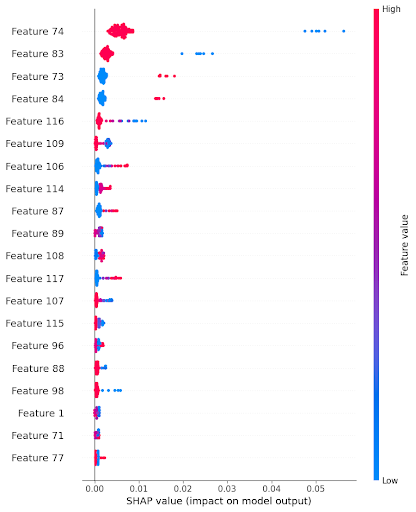